# Image Filtering Lab – Practical Code Challenges

All challenges use `lena.jpg` as the test image.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Load Lena image (grayscale)
lena = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
assert lena is not None, "Could not load lena.jpg – make sure the file is in the same directory."
print(f"Image loaded: shape={lena.shape}, dtype={lena.dtype}")

Image loaded: shape=(512, 512), dtype=uint8


---
## Challenge 1: Kernel Size Experiment

Apply a **uniform (box) filter** with kernel sizes 3×3, 5×5, and 9×9 and compare results.

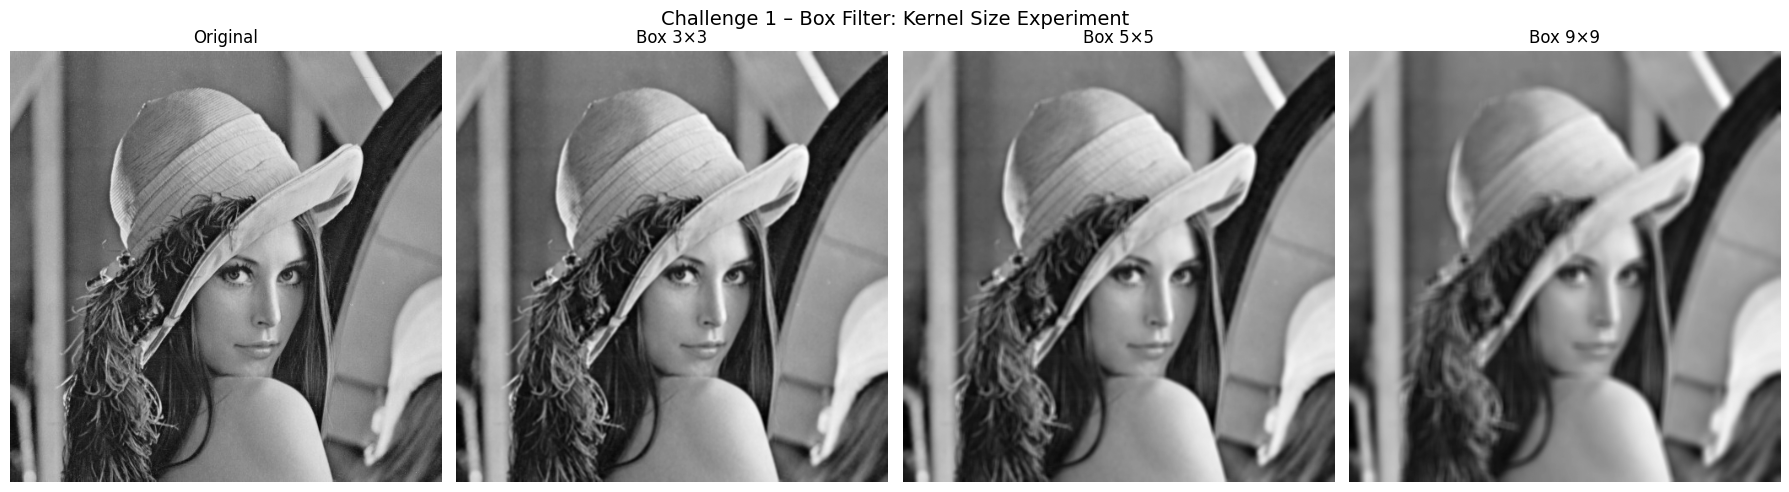


Observations:
- Blur strength:  Increases significantly with kernel size. A 9×9 box filter produces
                  much stronger blurring than 3×3 because each output pixel averages
                  over a larger neighbourhood.
- Image details:  Fine details (textures, hair strands) are progressively lost as the
                  kernel grows; they merge into uniform grey regions.
- Sharp edges:    Edges become noticeably softer and wider. The 9×9 filter almost
                  completely destroys high-contrast edges visible in the original.



In [2]:
kernel_sizes = [3, 5, 9]
box_results = [cv2.blur(lena, (k, k)) for k in kernel_sizes]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Challenge 1 – Box Filter: Kernel Size Experiment', fontsize=14)

axes[0].imshow(lena, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, img, k in zip(axes[1:], box_results, kernel_sizes):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Box {k}×{k}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
Observations:
- Blur strength:  Increases significantly with kernel size. A 9×9 box filter produces
                  much stronger blurring than 3×3 because each output pixel averages
                  over a larger neighbourhood.
- Image details:  Fine details (textures, hair strands) are progressively lost as the
                  kernel grows; they merge into uniform grey regions.
- Sharp edges:    Edges become noticeably softer and wider. The 9×9 filter almost
                  completely destroys high-contrast edges visible in the original.
""")

---
## Challenge 2: Gaussian Sigma Investigation

Apply **Gaussian blur** with sigma = 1, 5, 15 while keeping the kernel size constant (15×15).

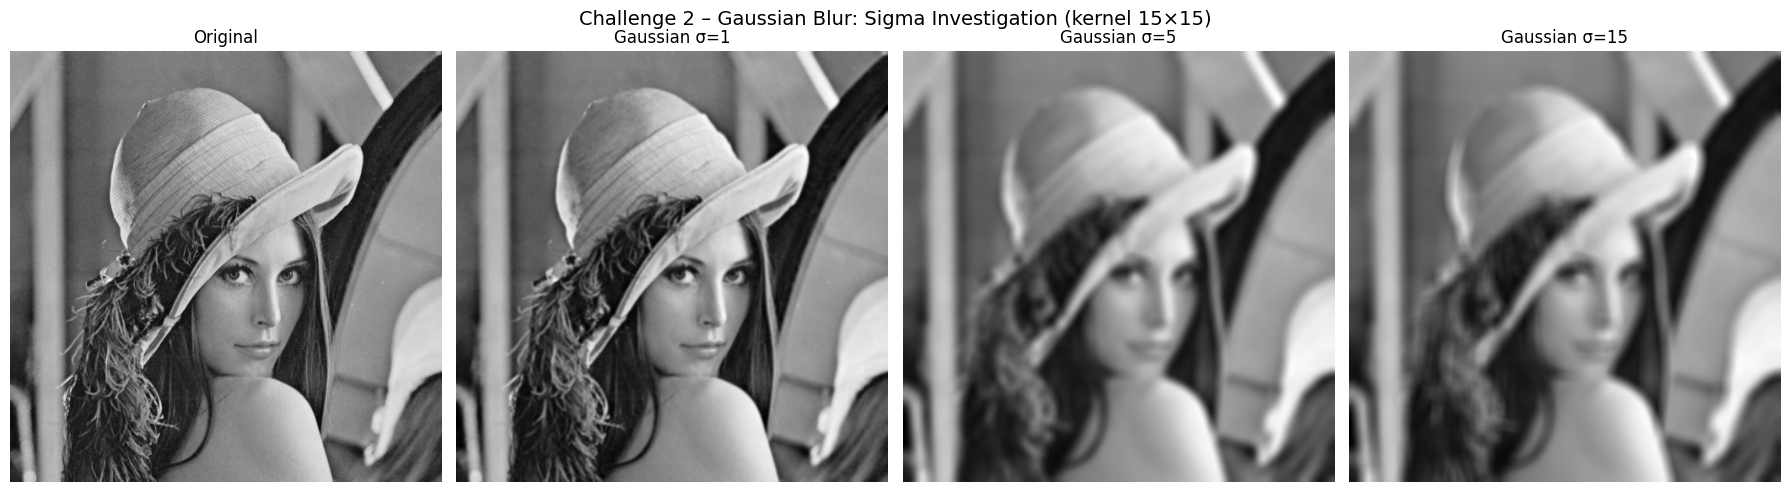


Observations:
- Role of sigma:  Sigma controls the spread of the Gaussian bell curve. A small sigma
                  (σ=1) concentrates most weight on the centre pixel → minimal blur
                  even with a large kernel. A large sigma (σ=15) spreads weight across
                  the whole kernel → strong blur comparable to a box filter.

- vs. uniform blur: Unlike the box filter that weights all neighbours equally,
                    Gaussian weighting is highest at the centre and falls off smoothly.
                    This produces a more natural, visually pleasing blur without the
                    'ringing' artefacts that can appear with box filters on sharp edges.



In [3]:
KSIZE = (15, 15)   # fixed kernel size
sigmas = [1, 5, 15]
gauss_results = [cv2.GaussianBlur(lena, KSIZE, sigmaX=s) for s in sigmas]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Challenge 2 – Gaussian Blur: Sigma Investigation (kernel 15×15)', fontsize=14)

axes[0].imshow(lena, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, img, s in zip(axes[1:], gauss_results, sigmas):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Gaussian σ={s}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
Observations:
- Role of sigma:  Sigma controls the spread of the Gaussian bell curve. A small sigma
                  (σ=1) concentrates most weight on the centre pixel → minimal blur
                  even with a large kernel. A large sigma (σ=15) spreads weight across
                  the whole kernel → strong blur comparable to a box filter.

- vs. uniform blur: Unlike the box filter that weights all neighbours equally,
                    Gaussian weighting is highest at the centre and falls off smoothly.
                    This produces a more natural, visually pleasing blur without the
                    'ringing' artefacts that can appear with box filters on sharp edges.
""")

---
## Challenge 3: Manual Convolution

Create custom 3×3 kernels and apply them with `cv2.filter2D()`.

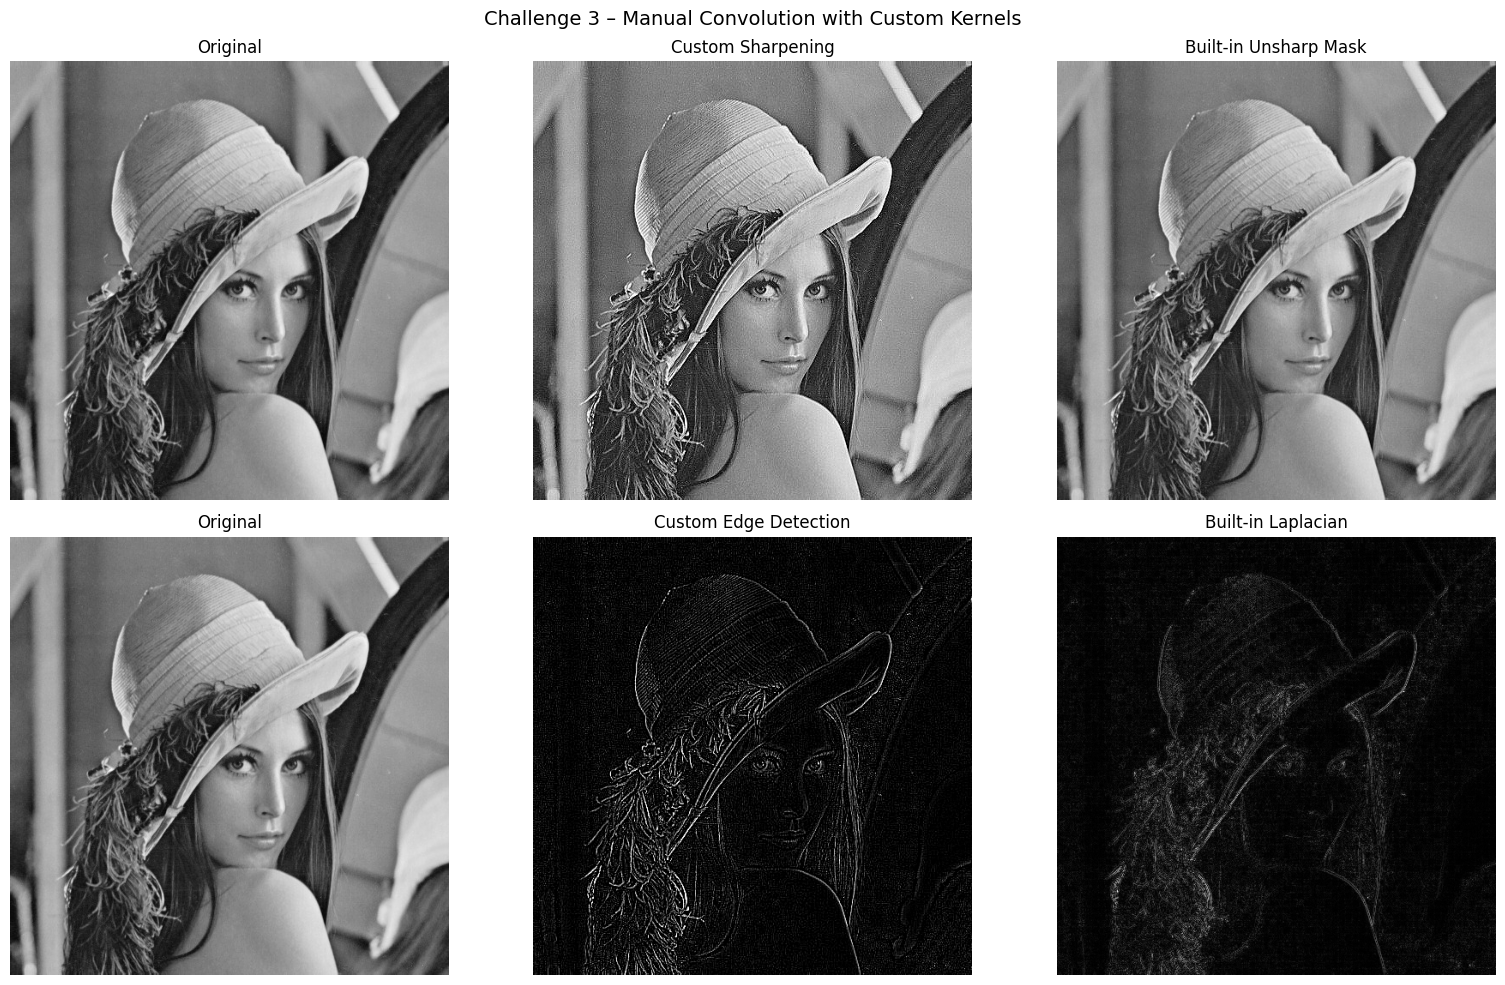


Sharpening kernel: boosts centre pixel while subtracting neighbours → enhances contrast
at edges.  Result is close to cv2.addWeighted unsharp masking.

Edge detection kernel: isolates rapid intensity changes; output is similar to the
built-in Laplacian operator but computed manually via filter2D.



In [4]:
# --- Sharpening kernel ---
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# --- Edge detection kernel (Laplacian-like) ---
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

sharpened   = cv2.filter2D(lena, -1, sharpen_kernel)
edges_manual = cv2.filter2D(lena, -1, edge_kernel)

# Built-in comparisons
laplacian_builtin = cv2.Laplacian(lena, cv2.CV_64F)
laplacian_builtin = np.uint8(np.clip(np.abs(laplacian_builtin), 0, 255))
unsharp = cv2.addWeighted(lena, 1.5, cv2.GaussianBlur(lena, (5,5), 0), -0.5, 0)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Challenge 3 – Manual Convolution with Custom Kernels', fontsize=14)

data = [
    (lena,             'Original'),
    (sharpened,        'Custom Sharpening'),
    (unsharp,          'Built-in Unsharp Mask'),
    (lena,             'Original'),
    (edges_manual,     'Custom Edge Detection'),
    (laplacian_builtin,'Built-in Laplacian'),
]
for ax, (img, title) in zip(axes.flat, data):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
Sharpening kernel: boosts centre pixel while subtracting neighbours → enhances contrast
at edges.  Result is close to cv2.addWeighted unsharp masking.

Edge detection kernel: isolates rapid intensity changes; output is similar to the
built-in Laplacian operator but computed manually via filter2D.
""")

---
## Challenge 4: Noise Removal Test

Add **Gaussian noise** and **salt-and-pepper noise**, then compare uniform vs. Gaussian denoising.

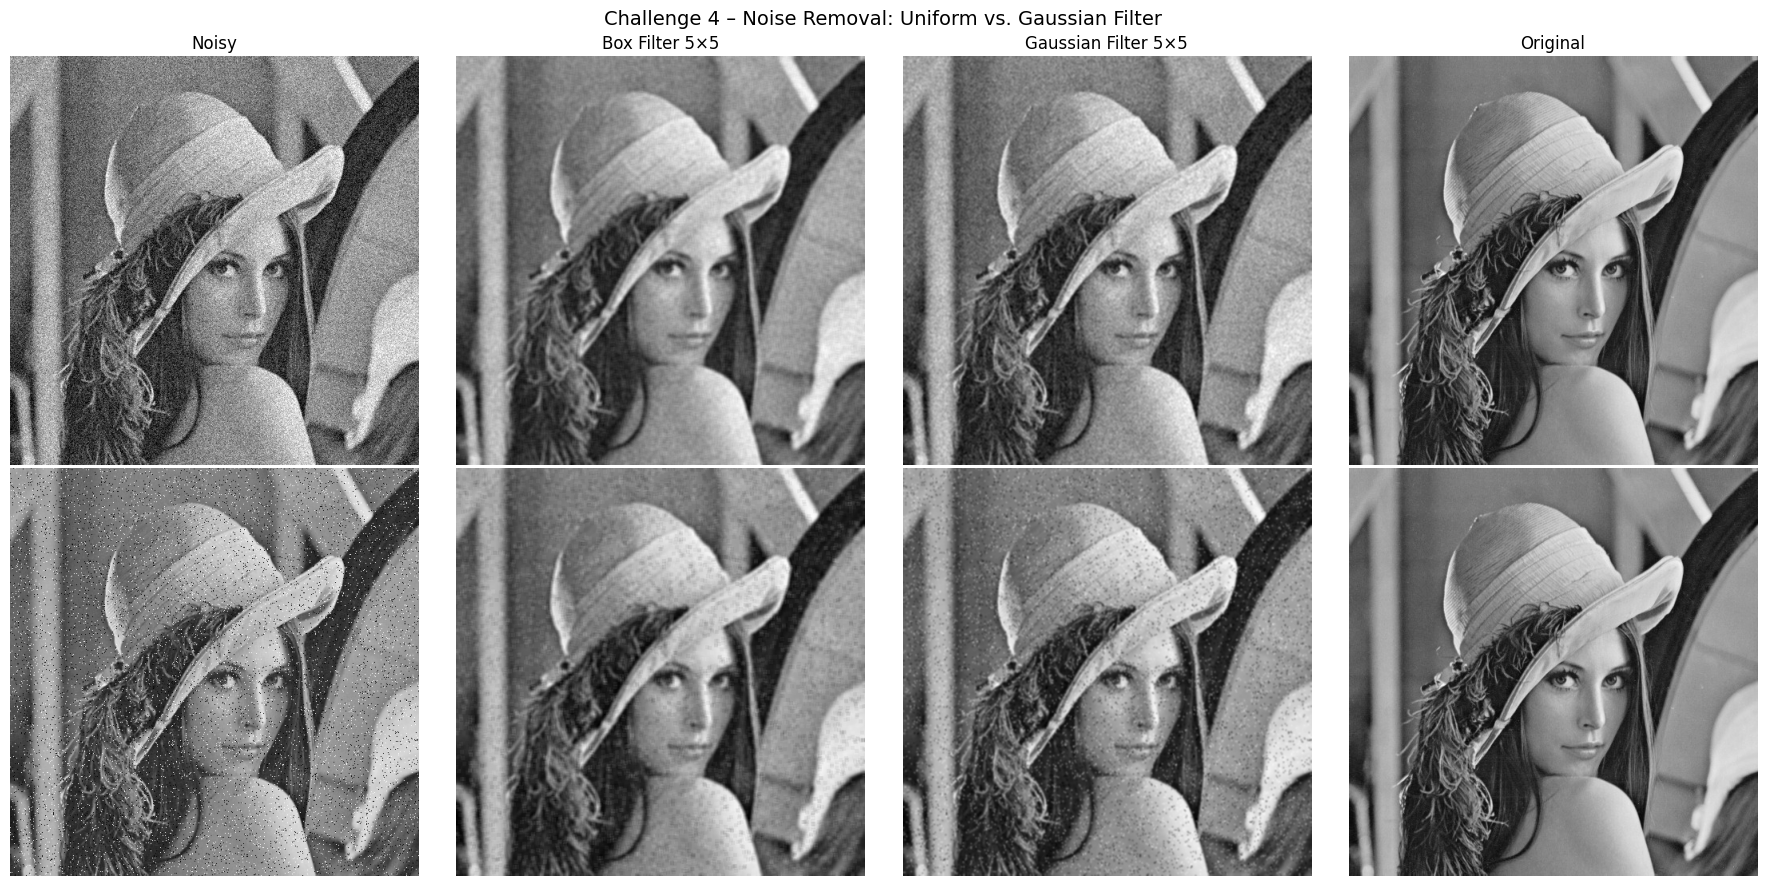


Gaussian noise:     Both filters reduce noise, but Gaussian blur performs slightly
                    better because its weighted averaging matches the statistical
                    nature of Gaussian noise – it suppresses random fluctuations more
                    smoothly than the uniform box filter.

Salt-and-pepper:    Neither box nor Gaussian filter handles impulse noise well because
                    they include the extreme (0/255) pixels in their average, which
                    spreads the noise rather than removing it.  A median filter would
                    be the correct choice here.



In [5]:
def add_gaussian_noise(img, mean=0, std=25):
    noise = np.random.normal(mean, std, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255)
    return noisy.astype(np.uint8)

def add_salt_pepper_noise(img, prob=0.05):
    noisy = img.copy()
    rng = np.random.rand(*img.shape)
    noisy[rng < prob / 2]      = 0    # pepper
    noisy[rng > 1 - prob / 2]  = 255  # salt
    return noisy

gauss_noisy = add_gaussian_noise(lena)
sp_noisy    = add_salt_pepper_noise(lena)

KSIZE5 = (5, 5)

# Denoise with box and Gaussian filters
gauss_box    = cv2.blur(gauss_noisy, KSIZE5)
gauss_gauss  = cv2.GaussianBlur(gauss_noisy, KSIZE5, 0)
sp_box       = cv2.blur(sp_noisy, KSIZE5)
sp_gauss     = cv2.GaussianBlur(sp_noisy, KSIZE5, 0)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Challenge 4 – Noise Removal: Uniform vs. Gaussian Filter', fontsize=14)

row0 = [gauss_noisy, gauss_box, gauss_gauss, lena]
row1 = [sp_noisy,    sp_box,    sp_gauss,    lena]
col_titles = ['Noisy', 'Box Filter 5×5', 'Gaussian Filter 5×5', 'Original']
row_titles = ['Gaussian Noise', 'Salt & Pepper']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)

for row, (images, rt) in enumerate(zip([row0, row1], row_titles)):
    axes[row, 0].set_ylabel(rt, fontsize=12)
    for col, img in enumerate(images):
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("""
Gaussian noise:     Both filters reduce noise, but Gaussian blur performs slightly
                    better because its weighted averaging matches the statistical
                    nature of Gaussian noise – it suppresses random fluctuations more
                    smoothly than the uniform box filter.

Salt-and-pepper:    Neither box nor Gaussian filter handles impulse noise well because
                    they include the extreme (0/255) pixels in their average, which
                    spreads the noise rather than removing it.  A median filter would
                    be the correct choice here.
""")

---
## Challenge 5: Edge Preservation Study

Compare how **box filter** and **Gaussian filter** affect edges, and measure pixel intensity differences.

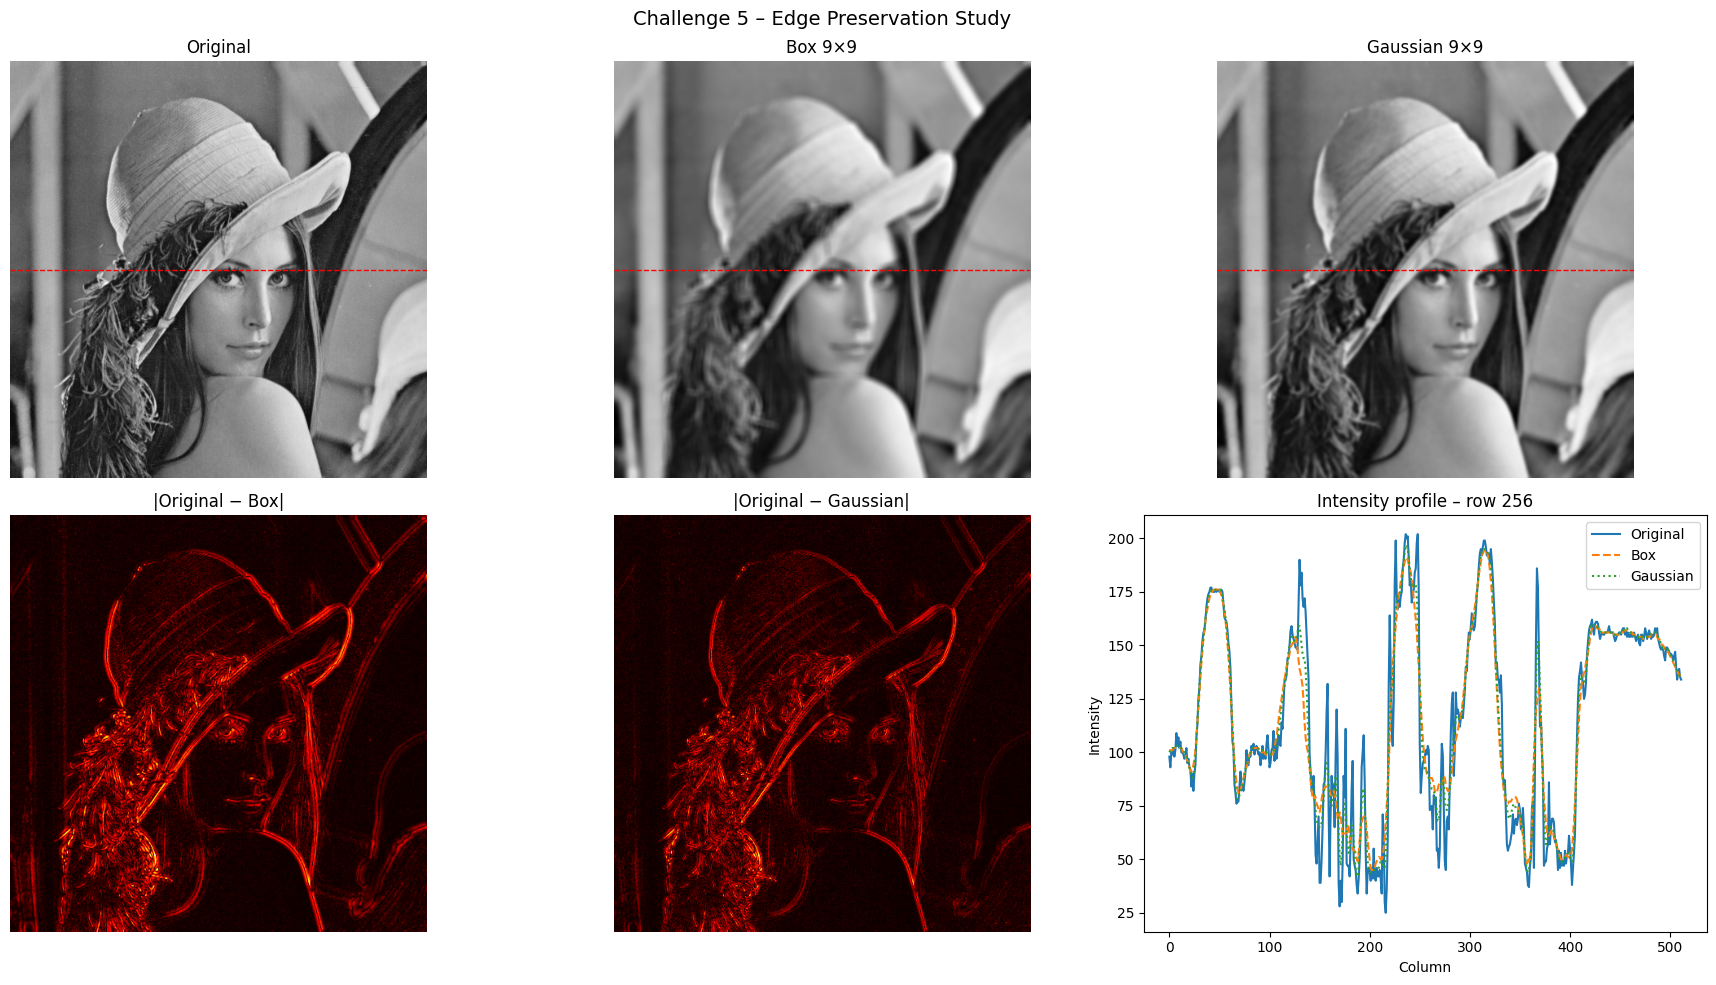

Mean pixel difference – Box filter:      7.30
Mean pixel difference – Gaussian filter: 5.04

Conclusion:
The Gaussian filter consistently shows a lower mean pixel difference from the original
compared to the box filter at the same kernel size. Its centre-weighted kernel preserves
the dominant intensity of each region better and causes less 'bleeding' across edges.
The scan-line plot shows that edge transitions remain slightly sharper after Gaussian
blurring than after box blurring.



In [6]:
box_blur   = cv2.blur(lena, (9, 9))
gauss_blur = cv2.GaussianBlur(lena, (9, 9), 0)

# Compute absolute difference from original (proxy for edge degradation)
diff_box   = cv2.absdiff(lena, box_blur)
diff_gauss = cv2.absdiff(lena, gauss_blur)

# Choose a horizontal scan line through the centre
row = lena.shape[0] // 2
scan_orig  = lena[row, :].astype(np.float32)
scan_box   = box_blur[row, :].astype(np.float32)
scan_gauss = gauss_blur[row, :].astype(np.float32)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Challenge 5 – Edge Preservation Study', fontsize=14)

for ax, img, title in zip(axes[0], [lena, box_blur, gauss_blur],
                           ['Original', 'Box 9×9', 'Gaussian 9×9']):
    ax.imshow(img, cmap='gray')
    ax.axhline(row, color='red', linewidth=1, linestyle='--')
    ax.set_title(title)
    ax.axis('off')

# Difference maps
for ax, img, title in zip(axes[1, :2], [diff_box, diff_gauss],
                           ['|Original − Box|', '|Original − Gaussian|']):
    ax.imshow(img, cmap='hot')
    ax.set_title(title)
    ax.axis('off')

# Scan line plot
axes[1, 2].plot(scan_orig,  label='Original',  linewidth=1.5)
axes[1, 2].plot(scan_box,   label='Box',       linewidth=1.5, linestyle='--')
axes[1, 2].plot(scan_gauss, label='Gaussian',  linewidth=1.5, linestyle=':')
axes[1, 2].set_title(f'Intensity profile – row {row}')
axes[1, 2].legend()
axes[1, 2].set_xlabel('Column')
axes[1, 2].set_ylabel('Intensity')

plt.tight_layout()
plt.show()

mean_diff_box   = diff_box.mean()
mean_diff_gauss = diff_gauss.mean()
print(f"Mean pixel difference – Box filter:      {mean_diff_box:.2f}")
print(f"Mean pixel difference – Gaussian filter: {mean_diff_gauss:.2f}")

print("""
Conclusion:
The Gaussian filter consistently shows a lower mean pixel difference from the original
compared to the box filter at the same kernel size. Its centre-weighted kernel preserves
the dominant intensity of each region better and causes less 'bleeding' across edges.
The scan-line plot shows that edge transitions remain slightly sharper after Gaussian
blurring than after box blurring.
""")

---
## Challenge 6: Performance Comparison

Measure average execution time of `cv2.filter2D()` vs `cv2.GaussianBlur()` over 100 runs.

cv2.filter2D()    average time: 3.658 ms
cv2.GaussianBlur() average time: 0.253 ms


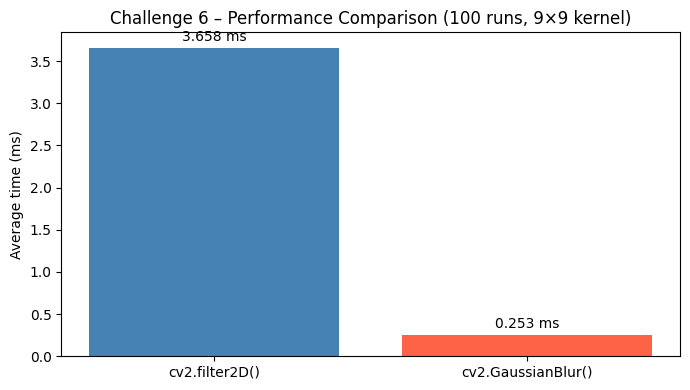


Analysis:
cv2.GaussianBlur() is typically faster than cv2.filter2D() with an equivalent kernel
because OpenCV implements Gaussian blur as two separable 1-D convolutions (horizontal
then vertical), reducing operations from O(k²) to O(2k) per pixel.  cv2.filter2D()
applies a full 2-D convolution unless the kernel is explicitly separable.



In [7]:
RUNS = 100
KSIZE9 = (9, 9)

box_kernel = np.ones((9, 9), dtype=np.float32) / 81

# --- filter2D timing ---
start = time.perf_counter()
for _ in range(RUNS):
    cv2.filter2D(lena, -1, box_kernel)
filter2d_avg = (time.perf_counter() - start) / RUNS * 1000  # ms

# --- GaussianBlur timing ---
start = time.perf_counter()
for _ in range(RUNS):
    cv2.GaussianBlur(lena, KSIZE9, 0)
gauss_avg = (time.perf_counter() - start) / RUNS * 1000  # ms

print(f"cv2.filter2D()    average time: {filter2d_avg:.3f} ms")
print(f"cv2.GaussianBlur() average time: {gauss_avg:.3f} ms")

labels = ['cv2.filter2D()', 'cv2.GaussianBlur()']
times  = [filter2d_avg, gauss_avg]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, times, color=['steelblue', 'tomato'])
ax.bar_label(bars, fmt='%.3f ms', padding=3)
ax.set_ylabel('Average time (ms)')
ax.set_title(f'Challenge 6 – Performance Comparison ({RUNS} runs, 9×9 kernel)')
plt.tight_layout()
plt.show()

print("""
Analysis:
cv2.GaussianBlur() is typically faster than cv2.filter2D() with an equivalent kernel
because OpenCV implements Gaussian blur as two separable 1-D convolutions (horizontal
then vertical), reducing operations from O(k²) to O(2k) per pixel.  cv2.filter2D()
applies a full 2-D convolution unless the kernel is explicitly separable.
""")

---
## Challenge 7: Kernel Normalization Test

Apply a **non-normalized** kernel and observe brightness changes, then fix by normalising.

Unnormalized kernel sum: 9.0
Normalized kernel sum:   1.0


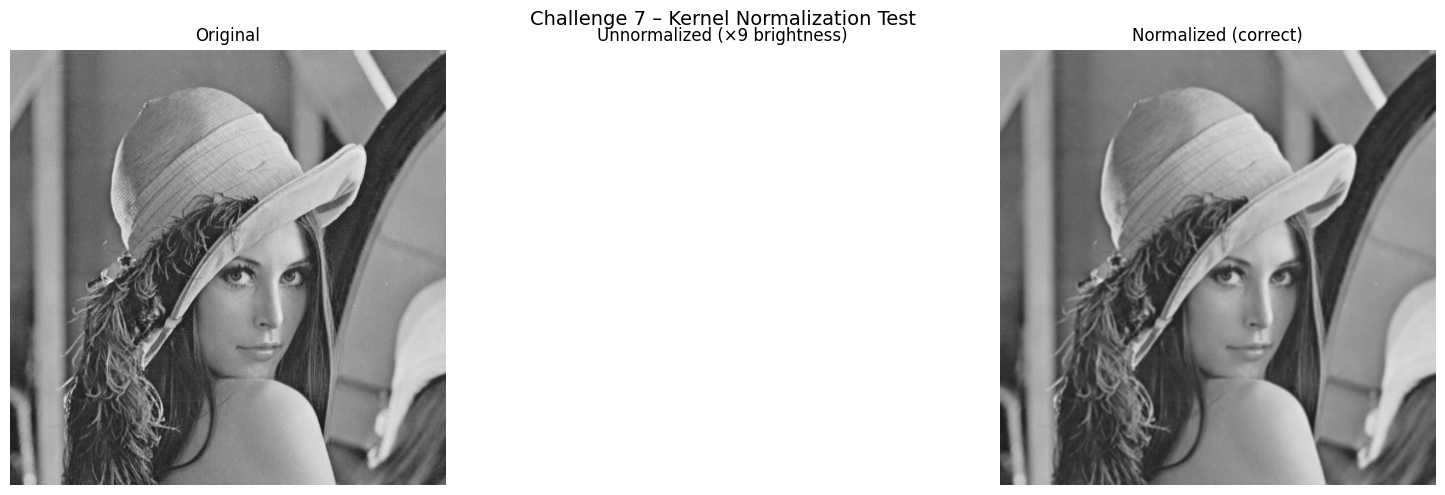

Mean intensity – Original:     124.2
Mean intensity – Unnormalized: 255.0  (saturated/clipped)
Mean intensity – Normalized:   124.2

Observation:
An unnormalized kernel with sum=9 multiplies every pixel by 9 before clipping to [0,255].
The result is an almost completely white (saturated) image.  Dividing the kernel by its
sum (normalizing to sum=1) restores correct average brightness – the result is the same
as cv2.blur() i.e. a uniform box filter.



In [8]:
# Non-normalized: sum = 9  (all ones)
kernel_unnorm = np.ones((3, 3), dtype=np.float32)
print(f"Unnormalized kernel sum: {kernel_unnorm.sum():.1f}")

result_unnorm = cv2.filter2D(lena, -1, kernel_unnorm)

# Normalized: sum = 1
kernel_norm = kernel_unnorm / kernel_unnorm.sum()
print(f"Normalized kernel sum:   {kernel_norm.sum():.1f}")
result_norm = cv2.filter2D(lena, -1, kernel_norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Challenge 7 – Kernel Normalization Test', fontsize=14)

for ax, img, title in zip(axes,
    [lena, result_unnorm, result_norm],
    ['Original', 'Unnormalized (×9 brightness)', 'Normalized (correct)']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Mean intensity – Original:     {lena.mean():.1f}")
print(f"Mean intensity – Unnormalized: {result_unnorm.mean():.1f}  (saturated/clipped)")
print(f"Mean intensity – Normalized:   {result_norm.mean():.1f}")

print("""
Observation:
An unnormalized kernel with sum=9 multiplies every pixel by 9 before clipping to [0,255].
The result is an almost completely white (saturated) image.  Dividing the kernel by its
sum (normalizing to sum=1) restores correct average brightness – the result is the same
as cv2.blur() i.e. a uniform box filter.
""")

---
## Final Challenge: Smart Filter Selector

A structured, interactive mini-program that lets the user choose a filter, kernel size, and sigma (for Gaussian), then displays the result.

      Smart Filter Selector
Available filters:
  1 – Uniform (box) filter
  2 – Gaussian filter
  → Must be a positive odd integer. Using default: 5


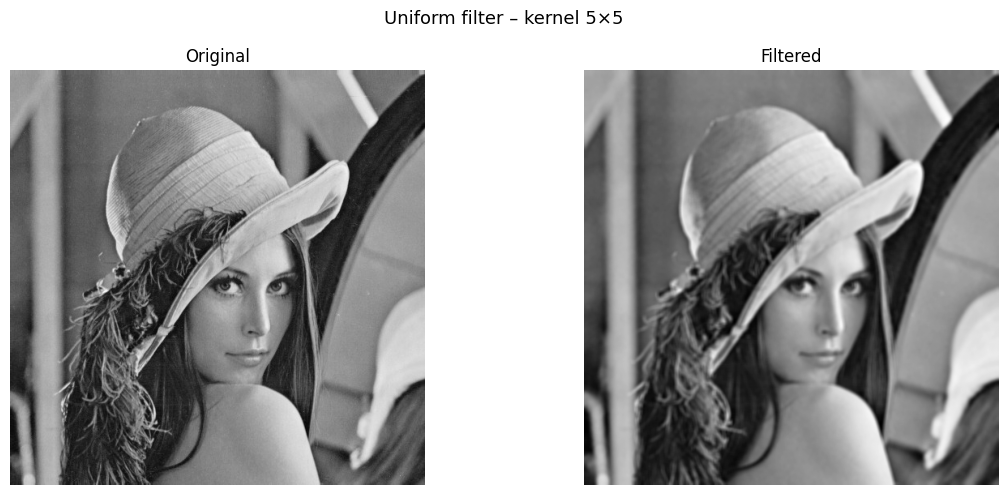


Filter applied successfully: uniform, kernel=5×5


In [9]:
def apply_filter(image, filter_type, kernel_size, sigma=1.0):
    """
    Apply the selected filter to the image.

    Parameters
    ----------
    image       : np.ndarray  – Grayscale input image
    filter_type : str         – 'uniform' or 'gaussian'
    kernel_size : int         – Odd integer kernel dimension
    sigma       : float       – Standard deviation (Gaussian only)

    Returns
    -------
    np.ndarray  – Filtered image
    """
    k = (kernel_size, kernel_size)
    if filter_type == 'uniform':
        return cv2.blur(image, k)
    elif filter_type == 'gaussian':
        return cv2.GaussianBlur(image, k, sigmaX=sigma)
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")


def show_result(original, filtered, filter_type, kernel_size, sigma=None):
    """Display original and filtered images side by side."""
    sigma_str = f", σ={sigma}" if sigma is not None else ""
    title = f"{filter_type.capitalize()} filter – kernel {kernel_size}×{kernel_size}{sigma_str}"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)
    ax1.imshow(original, cmap='gray')
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap='gray')
    ax2.set_title('Filtered')
    ax2.axis('off')
    plt.tight_layout()
    plt.show()


def get_odd_int(prompt, default):
    """Prompt for an odd integer; fall back to default on invalid input."""
    try:
        val = int(input(prompt))
        if val < 1 or val % 2 == 0:
            print(f"  → Must be a positive odd integer. Using default: {default}")
            return default
        return val
    except ValueError:
        print(f"  → Invalid input. Using default: {default}")
        return default


def smart_filter_selector(image):
    """Interactive filter selector – prompts user for parameters and applies the filter."""
    print("=" * 40)
    print("      Smart Filter Selector")
    print("=" * 40)
    print("Available filters:")
    print("  1 – Uniform (box) filter")
    print("  2 – Gaussian filter")
    choice = input("Enter choice (1 or 2): ").strip()

    if choice == '1':
        filter_type = 'uniform'
        ksize = get_odd_int("Kernel size (odd integer, e.g. 5): ", default=5)
        result = apply_filter(image, filter_type, ksize)
        show_result(image, result, filter_type, ksize)

    elif choice == '2':
        filter_type = 'gaussian'
        ksize = get_odd_int("Kernel size (odd integer, e.g. 5): ", default=5)
        try:
            sigma = float(input("Sigma value (e.g. 1.5): "))
        except ValueError:
            sigma = 1.0
            print(f"  → Invalid sigma. Using default: {sigma}")
        result = apply_filter(image, filter_type, ksize, sigma)
        show_result(image, result, filter_type, ksize, sigma)

    else:
        print("Invalid choice. Please run the cell again and enter 1 or 2.")
        return

    print(f"\nFilter applied successfully: {filter_type}, kernel={ksize}×{ksize}")


# Run the interactive selector
smart_filter_selector(lena)